In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
from sklearn.model_selection import  KFold , train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans , AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram , linkage

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [16]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [18]:
df= df.drop('CustomerID', axis = 1)

In [19]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

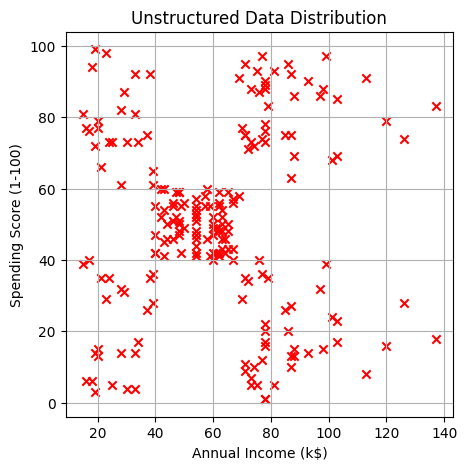

In [4]:
plt.figure(figsize=(5, 5))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], color='red', marker='x')
plt.title('Unstructured Data Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

In [21]:
wcss = []
silScore = []

for k in range (2, 15):
        km = KMeans(n_clusters=k)
        prediction = km.fit_predict(X)
        
        score = silhouette_score(X, prediction)
        wcss.append(km.inertia_)
        silScore.append(score)

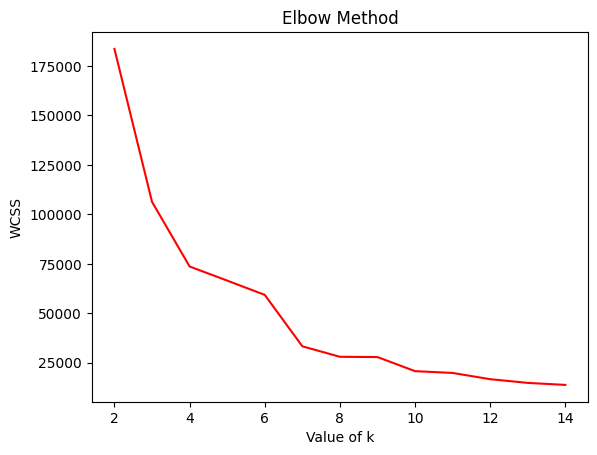

In [22]:
plt.title("Elbow Method")
plt.xlabel("Value of k")
plt.ylabel("WCSS")
plt.plot(range(2, 15), wcss, c = 'r')
plt.show()

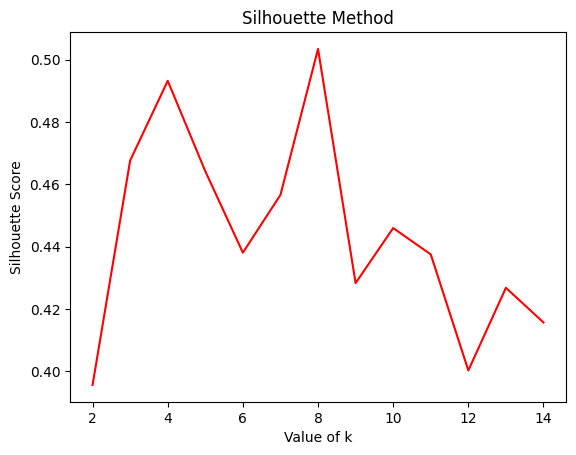

In [23]:
#Silhouette Method
plt.title("Silhouette Method")
plt.xlabel("Value of k")
plt.ylabel("Silhouette Score")
plt.plot(range(2, 15), silScore, c = 'r')
plt.show()

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, df, test_size=0.2, random_state=42)

In [7]:
sse = []
silhouette_scores_kmeans = []
silhouette_scores_agg = []
k_range = range(2, 11)

In [8]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    sse.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_train, kmeans.labels_))

    agg_clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_labels = agg_clustering.fit_predict(X_train)
    silhouette_scores_agg.append(silhouette_score(X_train, agg_labels))

optimal_k_elbow = np.diff(sse, 2).argmin()

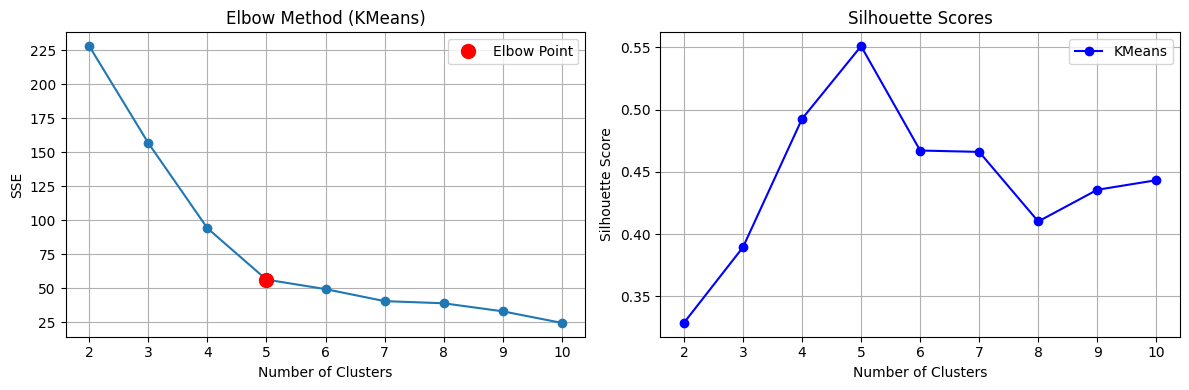

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, sse, marker='o')
plt.plot(optimal_k_elbow, sse[optimal_k_elbow - 2], 'ro', markersize=10, label='Elbow Point')
plt.title('Elbow Method (KMeans)')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.grid(True)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores_kmeans, marker='o', label='KMeans', color='blue')
#plt.plot(k_range, silhouette_scores_agg, marker='s', label='Agglomerative', color='orange')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
optimal_k_kmeans = k_range[np.argmax(silhouette_scores_kmeans)]
optimal_k_agg = k_range[np.argmax(silhouette_scores_agg)]
optimal_k_kmeans = min(optimal_k_kmeans, optimal_k_elbow)

In [15]:
kmeans = KMeans(n_clusters=final_optimal_k_kmeans, random_state=42)
kmeans.fit(X_train)
kmeans_train_pred = kmeans.predict(X_train)
kmeans_test_pred = kmeans.predict(X_test)
unique_clusters = np.unique(kmeans_train_pred)
plt.figure(figsize=(5, 5))
for cluster in unique_clusters:
    plt.scatter(X_train[kmeans_train_pred == cluster, 0], X_train[kmeans_train_pred == cluster, 1], label=f'Training Cluster {cluster + 1}', alpha=0.6, s=100)
    plt.scatter(X_test[kmeans_test_pred == cluster, 0], X_test[kmeans_test_pred == cluster, 1], label=f'Testing Cluster {cluster + 1}', marker='^', alpha=1.0, s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='purple', marker='*', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'final_optimal_k_kmeans' is not defined